# Curating a microviridin-focused MdnC set for ConSurf — HMM classification route

**What this notebook produces:** one alignment file containing only *confirmed lactone-forming* microviridin macrocyclases (MdnC/MvdD-type), which you upload to ConSurf. The goal is to make the microviridin-specific **α7 leader-recognition cluster (E191 / D192 / N195)** show up as conserved — it didn't in your earlier broad run, because that homolog set was 93% non-microviridin enzymes.

---

## The story so far (why this notebook replaces the last one)

1. Your **broad ConSurf run worked** as a pipeline: the ATP-binding core (K125, K166, Q207, E215, D281, E294, N296) and the DxR arginine (R243) all came back grade 9 (most conserved). But α7 was grade 3–5, because the homolog set was dominated by distant ATP-grasp enzymes that don't recognize a microviridin leader at all.
2. You built a **RODEO Group-1 set** (824 cyclases) — function-verified microviridin enzymes from Ramesh et al. 2021.
3. You tried to split them into lactone-formers (MdnC-type, keep) vs lactam-formers (MdnB-type, drop) by **comparing each sequence's percent identity to two reference structures**. It didn't separate: about half the sequences piled up near zero difference. Fixing the scoring (BLOSUM62 + gap penalties) didn't help.
4. **The literature explains why, and gives the fix.** MdnB and MdnC are only ~40% identical *to each other*, and the features distinguishing them are **local** (the α7 helix, the β9β10 hairpin, the active site) — not spread across all ~325 amino acids. So a single whole-sequence identity number physically cannot separate them. But the two types are **separately curated protein families with their own statistical models**, and RODEO itself used exactly those models. You can look the answer up instead of re-deriving it.

**The two families you're separating:**

| Type | Names | Chemistry | Family IDs |
|---|---|---|---|
| **Keep** | MdnC / MvdD | forms **ester** rings (lactones) | TIGR04184 / IPR026439 |
| **Drop** | MdnB / MvdC | forms **amide** rings (lactams) | TIGR04185 / IPR026446 |

---

## How this notebook is organized

Two kinds of cells:

- **`[FILLED]`** — plumbing, or code you already wrote and got working. Run it, don't retype it.
- **`[YOUR TURN]`** — the steps that carry a real decision. You get the concept, the reasoning, and hints; you write the code. This is where the learning is.

**Every technical term is defined in plain language when it first appears, and collected in the Glossary at the very end of this notebook.**

**Pipeline map:**
`Part 0` setup → `Part A` gather RODEO Group 1 *(carried — done)* → `Part B` classify by HMM *(the new core)* → `Part C` free validations → `Part D` curate → `Part E` align → `Part F` tree → `Part G` trim to ≤300 → `Part H` readiness → ConSurf


---
# Part 0 — Setup  `[FILLED]`

### 0.1 — Imports and paths

Nothing new here. `DATA` is your `data/` folder — the notebook looks one level up first (in case you're running from a `notebooks/` subfolder), otherwise alongside.

In [1]:
from pathlib import Path
import time, shutil, statistics, subprocess, sys
from collections import Counter

import pandas as pd
from Bio import Entrez, SeqIO
from Bio.Seq import Seq
from Bio.Align import PairwiseAligner, substitution_matrices
import matplotlib.pyplot as plt

Entrez.email = "phamminh1@ufl.edu"
DATA = Path("../data") if Path("../data").exists() else Path("data")
DATA.mkdir(exist_ok=True)
print("data folder:", DATA.resolve())

data folder: /Users/phamchutuanminh/Documents/microviridin-project/data


### 0.2 — Load the two reference proteins

- **5IG9** = the crystal structure of MdnC (the lactone-former). This is your *query* — the protein you actually want ConSurf grades for.
- **5IG8** = the crystal structure of MdnB (the lactam-former). You need it as a comparison point.

*(A "crystal structure" here just means an experimentally determined 3D model of the protein, stored in the Protein Data Bank — the PDB — under a 4-character code like `5IG9`. You downloaded the amino-acid sequences of these into `data/`.)*

`max(..., key=len)` picks the longest chain in the file, because PDB FASTA files often contain several chains and you want the full-length protein, not a short fragment.

In [2]:
def load_ref(tag):
    """Find a FASTA in DATA whose filename contains `tag`, return its longest sequence."""
    hits  = [p for p in DATA.glob("*.fasta") if tag in p.name.lower()]
    hits += [p for p in DATA.glob("*.txt")   if tag in p.name.lower()]
    if not hits:
        raise FileNotFoundError(f"Put the {tag.upper()} FASTA in {DATA.resolve()}")
    return max(SeqIO.parse(hits[0], "fasta"), key=lambda r: len(r.seq))

query_record = load_ref("5ig9")                      # MdnC — lactone-former — YOUR QUERY
query_record.id = "MdnC_5IG9_query"; query_record.description = "MdnC query"
query_seq = str(query_record.seq); QLEN = len(query_seq)

mdnb_ref = load_ref("5ig8")                          # MdnB — lactam-former — comparison
mdnb_seq = str(mdnb_ref.seq)

print(f"MdnC query (5IG9): {QLEN} aa")
print(f"MdnB ref   (5IG8): {len(mdnb_seq)} aa")

MdnC query (5IG9): 333 aa
MdnB ref   (5IG8): 335 aa


### 0.3 — Shared helpers

Your existing helpers, plus one upgrade worth understanding.

**`percent_identity_ungapped`** — takes two *aligned* strings (same length, with `-` characters marking gaps) and returns what % of the positions match. It only counts columns where **both** sequences have a real amino acid, skipping any column with a gap.

**`run_mafft`** — MAFFT is the program that builds a **multiple sequence alignment (MSA)**: it takes many sequences and inserts gaps so that equivalent positions line up in the same column. ConSurf reads conservation column-by-column off exactly this kind of alignment, so alignment quality directly determines your grades.

The upgrade: MAFFT has different **strategies** that trade speed for accuracy.
- `--auto` (what you used before) picks a strategy based on how many sequences you give it. At ~400 sequences it picks a *fast, less accurate* one called **FFT-NS-2** — a "progressive" method, meaning it aligns sequences in one pass and never revisits earlier decisions.
- `--localpair --maxiterate 1000` (nicknamed **L-INS-i**) is MAFFT's accuracy mode. It first works out how each *pair* of sequences aligns locally, uses that as evidence, then **iteratively refines** the whole alignment — going back and fixing earlier mistakes, up to 1000 times. Slower, but noticeably more accurate.

At your scale (~400 sequences × ~325 amino acids) L-INS-i takes minutes, not hours — and it improves everything downstream at once (the tree, the identity numbers, and the ConSurf grades). So it's the highest-return upgrade available. `accurate=True` switches it on.

In [3]:
def percent_identity_ungapped(a, b):
    """% identity over columns where BOTH sequences have a residue (gaps skipped).
    `a` and `b` must be ALIGNED strings of equal length."""
    s = t = 0
    for x, y in zip(a, b):
        if x != "-" and y != "-":
            t += 1; s += (x == y)
    return 100 * s / t if t else 0.0

def run_mafft(records, out_path, accurate=True):
    """Build a multiple sequence alignment.
    accurate=True  -> L-INS-i  (slow, high accuracy)   <- use for the real set
    accurate=False -> --auto   (fast, lower accuracy)  <- use for quick tests
    """
    if not shutil.which("mafft"):
        raise RuntimeError("MAFFT not installed. Run:  brew install mafft")
    tmp = out_path.with_suffix(".input.fasta")
    SeqIO.write(records, tmp, "fasta")
    flags = ["--localpair", "--maxiterate", "1000"] if accurate else ["--auto"]
    with open(out_path, "w") as o:
        subprocess.run(["mafft", *flags, str(tmp)], stdout=o, check=True)
    return list(SeqIO.parse(out_path, "fasta"))

def dedup(aligned_records, threshold=90.0):
    """Keep one representative per >threshold%-identical cluster.
    records[0] (the query) is always kept because `kept` starts empty."""
    kept = []
    for rec in aligned_records:
        if all(percent_identity_ungapped(str(rec.seq), str(k.seq)) < threshold for k in kept):
            kept.append(rec)
    return kept

def trim_all_gap_columns(records):
    """Remove alignment columns that are gaps in every sequence (they carry no information)."""
    cols = [i for i in range(len(records[0].seq)) if any(r.seq[i] != "-" for r in records)]
    for r in records:
        r.seq = Seq("".join(r.seq[i] for i in cols))
    return records

print("helpers ready")

helpers ready


---
# Part A — Gather the RODEO Group-1 cyclases  `[FILLED — your working code]`

This is what you already built and ran successfully (824 accessions). Carried forward unchanged so the notebook runs top-to-bottom.

**What the RODEO dataset is:** Ramesh et al. 2021 used a genome-mining tool called RODEO to scan bacterial genomes for graspetide gene clusters, and published a table of ~4,356 precursor peptides sorted into 24 groups. **Group 1 = microviridins** — your family. Each row is one precursor peptide, and lists the accession IDs (unique database identifiers for a protein) of the ATP-grasp cyclase enzymes found next to it in the genome.

### A.1 — Read the table and filter to Group 1  `[FILLED]`

**Why 742 rows collapse to fewer unique proteins:** one cyclase enzyme can modify many different precursor peptides, so the same accession repeats down a column. `.unique()` collapses those.

**Why ligase-3 is excluded:** you verified it's empty for every Group-1 row.

In [4]:
rodeo_raw = pd.read_excel(DATA / "Ramesh_Rodeo_data.xlsx", sheet_name="Precursors")
group1_df = rodeo_raw[rodeo_raw["Graspetide group"] == 1]

cols = ["ATP grasp ligase-1 accession ID",
        "ATP grasp ligase-2 accession ID"]     # ligase-3 is empty for Group 1

print(f"total rows in table : {len(rodeo_raw)}")
print(f"Group 1 rows        : {len(group1_df)}")

total rows in table : 4356
Group 1 rows        : 742


### A.2 — Collect accessions, remembering which column each came from  `[FILLED]`

The `origin` dict records whether each accession was found in the ligase-1 or ligase-2 column. You'll use it in Part C as a **free independent cross-check** on your HMM classification — the column position is decided by RODEO's gene-neighborhood scan, which knows nothing about your HMM scores, so agreement between them is real evidence.

`if acc not in origin` does double duty: it's the deduplication check *and* the origin record. First-seen wins, which cleanly handles the 3 accessions that appear in both columns.

In [5]:
origin = {}
accession_IDs = []
for short, col in [("L1", cols[0]), ("L2", cols[1])]:
    for acc in group1_df[col].dropna():
        if acc not in origin:
            origin[acc] = short
            accession_IDs.append(acc)

print(f"unique accessions: {len(accession_IDs)}   (expect 824)")
print("column split     :", Counter(origin.values()))

unique accessions: 824   (expect 824)
column split     : Counter({'L1': 429, 'L2': 395})


### A.3 — Download the protein sequences from NCBI  `[FILLED]`

**`Entrez.efetch`** downloads records from NCBI's databases. Requests go in batches of 50 (NCBI asks you not to hammer their servers with hundreds of individual requests), with `time.sleep(0.5)` pausing half a second between batches to stay polite.

This writes the sequences to a FASTA file, because HMMER (Part B) is a command-line program — it reads files from disk, not Python variables.

In [6]:
rodeo_fasta = DATA / "rodeo_g1_all.fasta"

if rodeo_fasta.exists():
    rodeo_g1 = list(SeqIO.parse(rodeo_fasta, "fasta"))
    print(f"Reusing saved file: {len(rodeo_g1)} sequences")
else:
    rodeo_g1 = []
    for i in range(0, len(accession_IDs), 50):
        h = Entrez.efetch(db="protein", id=",".join(accession_IDs[i:i+50]),
                          rettype="fasta", retmode="text")
        rodeo_g1.extend(SeqIO.parse(h, "fasta"))
        h.close(); time.sleep(0.5)
    SeqIO.write(rodeo_g1, rodeo_fasta, "fasta")
    print(f"Fetched and saved {len(rodeo_g1)} sequences")

print(f"Group 1 cyclases: {len(rodeo_g1)}   (expect 824)")

Reusing saved file: 824 sequences
Group 1 cyclases: 824   (expect 824)


---
# Part B — Classify by HMM  `[the new core]`

## What a profile HMM is, in plain language

Your pairwise approach used **one scoring rule for every position**: BLOSUM62 says swapping Asp→Glu costs the same whether it happens at position 12 or position 192. That's why it failed — your ~325 positions all voted equally, so the handful of positions that actually distinguish the two enzyme types got outvoted by 300 positions of shared scaffold.

A **profile HMM** ("profile hidden Markov model") is a statistical model of a protein family that is **position-specific**. You build it from an alignment of known family members, and for *each column* it learns:
- which amino acids actually occur there, and how often
- how tolerated insertions and deletions are *at that particular spot*

So a strictly conserved catalytic Asp gets a sharp, demanding profile — anything else scores badly. A floppy surface loop gets a permissive one — almost anything passes. **The model automatically weights the diagnostic positions and ignores the noise.** That's exactly the "the signal is local, not global" problem, solved inside the model.

## What HMMER is

**HMMER** (pronounced "hammer", from hmmer.org) is the standard free program for working with profile HMMs. It's a **command-line tool** — you run it in Terminal, it reads files and writes files. It is not a Python library. The parts you need:

| Program | What it does |
|---|---|
| `hmmbuild` | build a profile HMM from an alignment |
| `hmmpress` | index a file of HMMs so `hmmscan` can search it fast |
| `hmmscan` | search **your sequences** against **a database of HMMs** → *"which family is this protein?"* ← **your question** |
| `hmmsearch` | search **one HMM** against **a database of sequences** → *"which proteins are in this family?"* |

## Bit score vs E-value — the one concept to get right

HMMER reports two numbers per hit, and using the wrong one will mislead you:

- **Bit score** — how much better the sequence fits the model than it fits random background noise. It depends *only* on the sequence and the model. Higher = better fit.
- **E-value** ("expect value") — how many hits this good you'd expect to see **by chance** given the size of the database you searched. Same sequence, same model, but a bigger database → worse E-value. It's a property of the *search*, not of the match.

**For "does this protein fit family A or family B better?", compare bit scores.** The E-value would be comparing apples to oranges. The **difference in bit score between the two models** is your confidence measure — the principled replacement for the ±3 identity margin you invented earlier.

## Gathering thresholds — curated cutoffs you get for free

Curated models (TIGRFAM, Pfam) ship with a **gathering threshold (GA)** baked into the file: the bit score above which the curators say "this sequence is a genuine member of this family." This is a gift — it converts a judgment call into a lookup, and gives you a cleaner decision rule than just "higher score wins":

| Passes GA for... | Meaning | Action |
|---|---|---|
| TIGR04184 only | confident **ester-former** (MdnC-type) | **KEEP** |
| TIGR04185 only | confident lactam-former (MdnB-type) | drop |
| **both** | genuinely ambiguous | exclude from focused run |
| **neither** | not a microviridin cyclase at all | drop |

The flag `--cut_ga` tells HMMER to apply these automatically. **Suggestion: run *without* it first** so you can see the raw bit scores and their distribution (the honest version of the histogram you made), then apply GA as your decision rule.

### B.1 — Install HMMER  

In Terminal: `brew install hmmer`

Then run the cell below to confirm Python can see it. `shutil.which` just checks whether a command exists on your system.

In [7]:
for tool in ["hmmscan", "hmmsearch", "hmmpress", "hmmbuild", "mafft"]:
    path = shutil.which(tool)
    print(f"{tool:12s} {'OK  ' + path if path else 'MISSING'}")

hmmscan      OK  /opt/homebrew/bin/hmmscan
hmmsearch    OK  /opt/homebrew/bin/hmmsearch
hmmpress     OK  /opt/homebrew/bin/hmmpress
hmmbuild     OK  /opt/homebrew/bin/hmmbuild
mafft        OK  /opt/homebrew/bin/mafft


### B.2 — Get the two HMM files  `[YOUR TURN]`

You need two files: the model for **TIGR04184** (MvdD / ester-former) and **TIGR04185** (MvdC / lactam-former).

**Background on the names:** *TIGRFAM* was a curated collection of protein-family HMMs (originally from The Institute for Genomic Research, later JCVI). It was transferred to **NCBI** and now lives under the name **NCBIfam**. *InterPro* is a separate umbrella database that cross-references many signature databases and assigns its own IDs — which is why the same family has two labels (TIGR04184 = IPR026439).

**Where to look:**
- NCBI's FTP site hosts the NCBIfam/TIGRFAM HMM library
- The InterPro entry pages for **IPR026439** and **IPR026446** list the member signatures and link out to them

**I'm not confident enough of the current exact download URL to have you chase one I half-remember — if you hit a wall, tell me and I'll pin down where these live now.**

**What the file should look like:** an HMM file is plain text. Open it and you should see a header block starting with `HMMER3/f`, a `NAME` line (e.g. `TIGR04184`), a `GA` line (the gathering threshold), and then a long numeric table — one row per position in the model. If you can see the `NAME` and `GA` lines, you have the right thing.

**If the download turns into a chase, you have two fallbacks:**
1. **Build your own HMMs** with `hmmbuild` from confirmed members of each family (needs a curated seed alignment of each type — some work).
2. **Skip to the tree route (Part F)** — it needs **no external files at all**, just MAFFT and a tree program on sequences you already have. It's a legitimate classifier, not only a validator.

**Your task:** get both files into `data/`, then combine them into one file and index it with `hmmpress` so `hmmscan` can search both at once. Concatenating two text files is just `cat file1 file2 > combined` in Terminal, or you can do it in Python.

In [8]:
# TODO(you): get TIGR04184.HMM and TIGR04185.HMM into DATA, then:    
hmm_db = DATA / "mvd_families.hmm"
#   2. run hmmpress on it (creates several index files alongside it)
for ext in [".h3m", ".h3i", ".h3f", ".h3p"]:
    index_file = hmm_db.with_suffix(hmm_db.suffix + ext)
    if index_file.exists():
        index_file.unlink()

subprocess.run(["hmmpress", str(hmm_db)], check=True)
#   - hmmpress refuses to run if index files already exist -> delete them or ignore the error
print(open(DATA/"TIGR04184.HMM").read()[:400])

#you should see  HMMER3/f ... NAME  TIGR04184 ... GA  <number>



Working...    done.
Pressed and indexed 2 HMMs (2 names and 2 accessions).
Models pressed into binary file:   ../data/mvd_families.hmm.h3m
SSI index for binary model file:   ../data/mvd_families.hmm.h3i
Profiles (MSV part) pressed into:  ../data/mvd_families.hmm.h3f
Profiles (remainder) pressed into: ../data/mvd_families.hmm.h3p
HMMER3/f [3.1b2 | February 2015]
NAME  ATPgraspMvdD
ACC   TIGR04184.1
DESC  MvdD family ATP-grasp ribosomal peptide maturase
LENG  321
ALPH  amino
RF    no
MM    no
CONS  yes
CS    no
MAP   yes
DATE  Fri Nov  2 18:34:33 2018
NSEQ  8
EFFN  0.683594
CKSUM 1223935159
GA    475 475
TC    475 475
NC    450 450
STATS LOCAL MSV      -11.2292  0.70078
STATS LOCAL VITERBI  -11.9477  0.70078
STATS LOCAL FOR


### B.3 — Positive control: test on two known proteins  `[YOUR TURN]`

**Do this before classifying all 824.** This is the same logic as your α7 "answer key": prove the tool recovers what's already known before trusting it on what isn't.

Two accessions with published, confirmed identities from *Microcystis aeruginosa*:

| Accession | Known identity | Should score higher against |
|---|---|---|
| **WP_012265553** | MvdD — the **ester**-former | TIGR04184 |
| **WP_012265554** | MvdC — the **amide**-former | TIGR04185 |

If your setup calls these two correctly, the pipeline is sound. If it doesn't — wrong files, wrong invocation, or swapped labels — you want to know **now**, not after classifying 824 sequences.

**What to do:** fetch those two sequences (reuse the `Entrez.efetch` pattern from A.3), write them to a small FASTA, and run `hmmscan` against your combined HMM database. Read the output by eye — for this test, the human-readable output is perfect.

In [9]:
# TODO(you): positive control
#   1. fetch WP_012265553 and WP_012265554 via Entrez.efetch
hD = Entrez.efetch(db = "protein", id = "WP_012265553", 
                   rettype = "fasta", retmode = "text")
hC = Entrez.efetch(db = "protein", id = "WP_012265554", 
                   rettype = "fasta", retmode = "text")
#   2. SeqIO.write them to DATA/"positive_control.fasta"
CD = [SeqIO.read(hD, "fasta"), SeqIO.read(hC, "fasta")]
hD.close()
hC.close()

ctrl_fasta = DATA/"positive_control.fasta"
SeqIO.write(CD, ctrl_fasta, "fasta")


#   3. run:  subprocess.run(["hmmscan", str(hmm_db), str(ctrl_fasta)], ...)
# What you're looking for in the output: for each query sequence, a short table of
# the models it hit, with an E-value and a bit score. Check that
#   WP_012265553 -> best bit score on TIGR04184  (ester)
#   WP_012265554 -> best bit score on TIGR04185  (amide)
#
# to capture output ->  

r = subprocess.run(["hmmscan", str(hmm_db), str(ctrl_fasta)], 
                   capture_output=True, text=True, check = True)
print(r.stdout)

# hmmscan :: search sequence(s) against a profile database
# HMMER 3.4 (Aug 2023); http://hmmer.org/
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# query sequence file:             ../data/positive_control.fasta
# target HMM database:             ../data/mvd_families.hmm
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

Query:       WP_012265553.1  [L=324]
Description: MULTISPECIES: MvdD family ATP-grasp ribosomal peptide maturase [Microcystis]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model        Description
    ------- ------ -----    ------- ------ -----   ---- --  --------     -----------
   3.6e-171  555.4   0.0   4.1e-171  555.3   0.0    1.0  1  ATPgraspMvdD  MvdD family ATP-grasp rib

### B.4 — Classify all 824  `[YOUR TURN]`

Now run `hmmscan` on the full RODEO set.

**Use `--tblout <file>`.** By default HMMER prints a human-readable report designed for eyeballing — pretty, but painful to parse. `--tblout` writes a **tab-delimited summary table** instead: one row per hit, with columns for the target model name, the query sequence name, the E-value, and the bit score. That's what you want to load into pandas.

Runtime: seconds. This is one command over 824 sequences — HMMER is fast.

**Reading the output file:** lines beginning with `#` are comments/headers. The data lines are whitespace-separated (not strictly tabs, despite the name), and the first few columns are: target name, target accession, query name, query accession, full-sequence E-value, full-sequence bit score, ...

**Two parsing options:**
- `pd.read_csv(path, sep=r"\s+", comment="#", header=None)` — crude but works; you'd name columns by position
- `Bio.SearchIO.parse(path, "hmmer3-tab")` — Biopython's dedicated reader for this exact format; cleaner, gives you objects with named attributes

In [10]:
# TODO(you): run hmmscan over rodeo_fasta with --tblout, then parse the results.
from Bio import SearchIO
tbl = DATA / "rodeo_g1_hmmscan.tbl"
subprocess.run(["hmmscan","--cut_ga", "--tblout", str(tbl), str(hmm_db), str(rodeo_fasta)], 
                capture_output = True, text = True, check = True)
#
# Then build a tidy table: for each query sequence, its bit score against TIGR04184
# and against TIGR04185. Note a sequence may have a row for one model, both, or neither.
rows = []
for result in SearchIO.parse(tbl, "hmmer3-tab"):
    for hit in result:
        rows.append({
            "query": result.id,
            "model": hit.id,
            "bitscore": hit.bitscore})
df_raw = pd.DataFrame(rows)

# Suggested shape -> a DataFrame with columns:
#   query | score_04184 | score_04185 | delta (= score_04184 - score_04185)

# Hint: after parsing, a pivot is natural here — one row per query, one column per model.
#       Missing = the sequence didn't hit that model at all (treat as very low / NaN).
df_pivot = df_raw.pivot(index = "query", columns = "model", values = "bitscore").reset_index()

df_pivot = df_pivot.rename(columns={
    "ATPgraspMvdD": "score_04184",
    "ATPgraspMvdC": "score_04185"
})
if "score_04184" not in df_pivot.columns:
    df_pivot["score_04184"] = 0.0
if "score_04185" not in df_pivot.columns:
    df_pivot["score_04185"] = 0.0

all_queries = pd.DataFrame({"query": [rec.id for rec in rodeo_g1]})
df_final = pd.merge(all_queries, df_pivot, on = "query", how = "left").fillna(0.0)
df_final["delta"] = df_final["score_04184"] - df_final["score_04185"]
df_final.head()

,query,score_04185,score_04184,delta
0,ADZ80323.1,0.0,0.0,0.0
1,AGH69798.1,0.0,558.7,558.7
2,AGP40495.1,453.5,0.0,-453.5
3,AKE65548.1,0.0,556.9,556.9
4,AVK43357.1,0.0,565.1,565.1


### B.5 — Apply the decision rule  `[YOUR TURN]`

Turn bit scores into labels, and **look at the distribution before you trust it** — the same discipline that caught the pairwise failure.

**Two ways to decide, and I'd do both:**

1. **Higher-score-wins + a margin** — the direct analog of what you did before, but on bit scores instead of identity. Plot a histogram of `delta` (score_04184 − score_04185). **This time you should see genuine separation** — that's the test of whether HMMs solved the problem. If this histogram *also* piles up at zero, tell me, because that would mean something deeper is wrong.
2. **Gathering thresholds** — the curated, more defensible rule (the 4-way table above). You'd need each model's GA value: read it from the `GA` line in the HMM file, or re-run `hmmscan` with `--cut_ga` and see which hits survive.

**Compare the two rules.** If they agree, you're solid. Where they disagree, trust GA — it's curator knowledge, not your threshold.

**Produce:** `rodeo_C` — the list of confirmed ester-formers — plus a `Counter` showing how many landed in each of the four buckets.

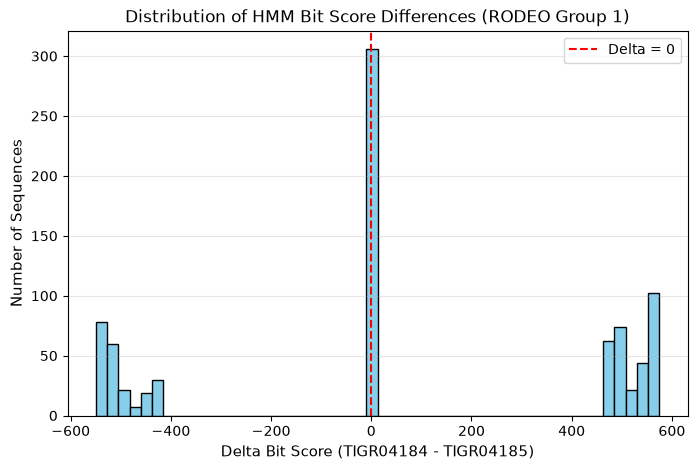

Counter({'neither': 306, 'MdnC': 303, 'MdnB': 215})

Saved 303 confirmed MdnC/MvdD sequences to rodeo_C!


In [11]:
# TODO(you):
#   1. plot a histogram of delta -> is it bimodal (two clear humps) this time?
plt.figure(figsize = (8, 5))
plt.hist(df_final["delta"], bins = 50, color = "skyblue", edgecolor = "black")
plt.axvline(0, color = "red", linestyle = "--", linewidth = 1.5, label = "Delta = 0")
plt.xlabel("Delta Bit Score (TIGR04184 - TIGR04185)", fontsize=11)
plt.ylabel("Number of Sequences", fontsize=11)
plt.title("Distribution of HMM Bit Score Differences (RODEO Group 1)", fontsize=12)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()
#   2. assign labels using the GA rule:
#         passes 04184 only  -> "C"       (KEEP)
#         passes 04185 only  -> "B"
#         passes both        -> "both"    (ambiguous, exclude)
#         passes neither     -> "neither" (not a microviridin cyclase)
labels = []
for _, row in df_final.iterrows():
    passes_C = row["score_04184"] >= 475
    passes_B = row["score_04185"] >= 425
    if passes_C and not passes_B:
        labels.append("MdnC")
    elif passes_B and not passes_C:
        labels.append("MdnB")
    elif passes_B and passes_C:
        labels.append("Both")
    else:
        labels.append("neither")
        
print (Counter(labels))

rodeo_C = [rec for rec, label in zip(rodeo_g1, labels) if label == "MdnC"]
print(f"\nSaved {len(rodeo_C)} confirmed MdnC/MvdD sequences to rodeo_C!")

# Keep the labels in a list that stays index-aligned with rodeo_g1, so Part C
# can cross-tabulate them (same trick as your zip() before).

/var/folders/n3/8nybd1nd4qsdhg34p50z2zdc0000gn/T/ipykernel_54710/1949804694.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


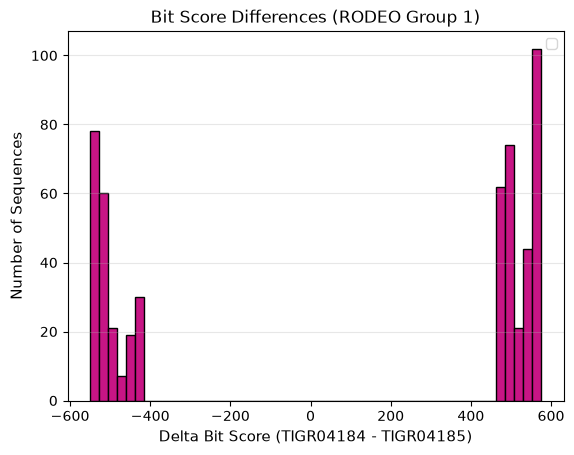

In [14]:
df_final["label"] = labels
mask = df_final["label"] != "neither"      # 
plt.hist(df_final.loc[mask, "delta"], bins=50, color = "mediumvioletred", edgecolor = "black")
plt.xlabel("Delta Bit Score (TIGR04184 - TIGR04185)", fontsize=11)
plt.ylabel("Number of Sequences", fontsize=11)
plt.title("Bit Score Differences (RODEO Group 1)", fontsize=12)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

---
# Part C — Two free validations  `[YOUR TURN]`

Both of these cost you almost nothing because you already stored the data. Neither is required to proceed — but both are the kind of thing that makes a methods section credible instead of hand-wavy.

### C.1 — Does RODEO's column order mean anything?  `[YOUR TURN]`

You saved `origin` (L1 vs L2 per accession). The literature says the ligase-1/ligase-2 columns reflect **gene order in the genome**, not enzyme function — but that was *inferred*, not confirmed from the paper's supplementary docs. You can test it directly.

**Build a contingency table:** column of origin (L1/L2) against HMM label (C/B/both/neither). A **contingency table** is just a grid counting how often each combination occurs — pandas does it in one call with `pd.crosstab(series_a, series_b)`.

**How to read the result:**
- **L1 almost all one label, L2 almost all the other** → RODEO does order them consistently, and your HMM calls independently agree. Two methods, same answer.
- **Both columns are a mix** → the ordering is arbitrary, which *retroactively justifies* classifying by signature rather than trusting the column. Finding a mess here is a win.

*Note:* `origin` is keyed by the accession string you sent to NCBI, but the sequence records' `.id` may come back slightly reformatted (version suffixes etc.). If lookups miss, that mismatch is the first suspect.

In [20]:
# TODO(you): cross-tabulate origin (L1/L2) against your HMM labels.

#   - build a list/Series of origins aligned to rodeo_g1
origins = [origin.get(rec.id, origin.get(rec.id.split(".")[0], "Unknown")) for rec in rodeo_g1]
pd.crosstab(pd.Series(origins, name="RODEO Column"), pd.Series(labels, name = "HMM Call"))

HMM Call,MdnB,MdnC,neither
RODEO Column,,,
L1,40,271,118
L2,175,32,188


### C.2 — Why did the pairwise method fail?  `[YOUR TURN]`

You still have your pairwise classifier. Cross-tabulate its calls against the HMM calls and you get a tidy demonstration of *why* global identity failed — useful for your writeup.

**Expected pattern:** the two methods should **agree on the tails** (the sequences with big identity differences, ±20 and beyond — those were real signal) and **disagree in the middle** (the pile near zero — that was noise). If you see exactly that, you've shown the pairwise method wasn't wrong everywhere, just blind in the region where it mattered.

Your pairwise classifier is below, carried forward unchanged. Note the aligner is built **once** outside the function (building it 824 times would reload BLOSUM62 from disk each call) — but that means if you edit its settings, you must re-run this cell for the change to take effect.

In [21]:
aligner = PairwiseAligner(mode="global")
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -11
aligner.extend_gap_score = -1

def classify_bc_pairwise(seq, margin=3.0):
    """OLD method, kept only as a cross-check. Returns (label, diff)."""
    aln_c = aligner.align(seq, query_seq)[0]
    aln_b = aligner.align(seq, mdnb_seq)[0]
    id_to_C = percent_identity_ungapped(aln_c[0], aln_c[1])
    id_to_B = percent_identity_ungapped(aln_b[0], aln_b[1])
    diff = id_to_C - id_to_B
    if diff >  margin: 
        return "C", diff
    elif diff < -margin: 
        return "B", diff
    else:                
        return "unsure", diff

pairwise_results = [classify_bc_pairwise(str(rec.seq)) for rec in rodeo_g1]
pairwise_labels = [res[0] for res in pairwise_results]

# TODO(you): run this over rodeo_g1, then pd.crosstab(pairwise_labels, hmm_labels).
pd.crosstab(pd.Series(pairwise_labels, name = "pairwise"), pd.Series(labels, name = "HMM call"))        
# Expected: agreement in the tails, disagreement in the middle.

HMM call,MdnB,MdnC,neither
pairwise,,,
B,210,0,108
C,0,303,109
unsure,5,0,89


In [24]:
tbl_ungated = DATA / "rodeo_g1_ungated.tbl"
subprocess.run(
    ["hmmscan", "-E", "1000", "--tblout", str(tbl_ungated), str(hmm_db), str(rodeo_fasta)],
    capture_output=True, text=True, check=True)

neither_ids = {rec.id for rec, lab in zip(rodeo_g1, labels) if lab == "neither"}
rows_ungated = []
for result in SearchIO.parse(tbl_ungated, "hmmer3-tab"):
    for hit in result:
        rows_ungated.append({
            "query": result.id,
            "model": hit.id,
            "bitscore": hit.bitscore})
df_raw_ung = pd.DataFrame(rows_ungated)

df_pivot_ung = df_raw_ung.pivot(index = "query", columns = "model", values = "bitscore").reset_index()

df_pivot_ung = df_pivot_ung.rename(columns={
    "ATPgraspMvdD": "score_04184",
    "ATPgraspMvdC": "score_04185"
})
df_neither = df_pivot_ung[df_pivot_ung["query"].isin(neither_ids)].copy()
print("--- Summary Statistics for 'neither' sequences against MvdD ---")
print(df_neither["score_04184"].describe())
print("\n--- Top 10 highest-scoring 'neither' sequences ---")
print(df_neither.sort_values(by="score_04184", ascending=False).head(10))
print("neither total:        ", len(neither_ids))
print("  had >=1 hit:        ", len(df_neither))
print("  had an MvdD score:  ", df_neither["score_04184"].notna().sum())
print("  no hit even at E1000:", len(neither_ids) - len(df_neither))

top_neither_ids = df_neither.sort_values(by = "score_04184", ascending = False).head(3)["query"].tolist()
print("--- Annotations for top 'neither' sequences ---")
for rec in rodeo_g1:
    if rec.id in top_neither_ids:
        print(f"ID: {rec.id}")
        print(f"Desc: {rec.description}")

handle = Entrez.efetch(db = "Protein", id = ",".join(top_neither_ids), rettype = "gp", retmode = "text")
gp_data = handle.read()
handle.close()
print(gp_data)

--- Summary Statistics for 'neither' sequences against MvdD ---
count    306.000000
mean     280.683333
std      112.600447
min      108.700000
25%      185.225000
50%      223.400000
75%      411.425000
max      474.800000
Name: score_04184, dtype: float64

--- Top 10 highest-scoring 'neither' sequences ---
model           query  score_04185  score_04184
258    WP_053326833.1        261.5        474.8
716    WP_179472397.1        258.8        474.5
533    WP_123262036.1        268.2        474.3
381    WP_089755755.1        259.9        474.1
700    WP_168237301.1        259.7        473.8
637    WP_149247160.1        261.7        473.7
641    WP_149676569.1        294.3        472.4
265    WP_056223091.1        261.7        472.2
49         PYS44393.1        286.5        471.9
672    WP_158761794.1        288.3        471.5
neither total:         306
  had >=1 hit:         306
  had an MvdD score:   306
  no hit even at E1000: 0
--- Annotations for top 'neither' sequences ---
ID: WP_

# Aligning the clade against MdnC and reading the three columns

In [30]:
from Bio import AlignIO
# Build the mini FASTA. Anchor + top ~6–8 by MvdD score:
mdnc_seq_record = CD[0]
mdnc_pool = [rec for rec, lab in zip(rodeo_g1, labels) if lab == "MdnC"]
extra_ids = {
    "RCJ32138.1",   # Nostoc punctiforme NIES-2108   — heterocystous, Nostocales (classic model, far from Microcystis)
    "BAZ30401.1",   # Cylindrospermum sp. NIES-4074  — heterocystous, a different Nostocalean family
    "BBD53456.1",   # Planktothrix agardhii NIES-204 — filamentous, Oscillatoriales
    "RAM51840.1",   # Hapalosiphonaceae cyanobacterium JJU2 — true-branching subsection V, the deep edge of cyano diversity
    "AKE65548.1",   # Microcystis aeruginosa NIES-2549 — unicellular Chroococcales; within-genus replicate of your anchor
}
extra_mdnc = [rec for rec in mdnc_pool if rec.id in extra_ids]
anchor = mdnc_seq_record            # WP_012265553 MdnC record (the ester control)
top_ids = df_neither.sort_values("score_04184", ascending=False).head(8)["query"].tolist()

subset = [anchor] + extra_mdnc + [rec for rec in rodeo_g1 if rec.id in top_ids]
SeqIO.write(subset, DATA/"anchor_plus_chryseo.fasta", "fasta")

s = str(anchor.seq)
print(s[190], s[191], s[194])   # 0-indexed 190/191/194 -> should print  E D N

# align with MAFFT L-INS-i
in_fasta = DATA / "anchor_plus_chryseo.fasta"
out_fasta = DATA / "anchor_plus_chryseo_aln.fasta"
with open(out_fasta, "w") as out_f:
    subprocess.run(["mafft", "--localpair", "--maxiterate", "1000", str(in_fasta)], 
                   stdout = out_f, 
                   check = True)

# map residue → column, then read down
aln = AlignIO.read(DATA/"anchor_plus_chryseo_aln.fasta", "fasta")
anchor_row = next(r for r in aln if r.id == anchor.id)

# TODO(you): iterate over enumerate(str(anchor_row.seq)); keep a counter that
target_indices = {190, 191, 194}
a7_cols = []
residue_counter = -1

for index, char in enumerate(str(anchor_row.seq)):
    if char != "-":
        residue_counter += 1
        if residue_counter in target_indices:
            a7_cols.append(index)
#   increments only on non-gap chars; when it equals 191/192/195, store that column index.
# Then for each stored column, print aln[:, col] down every row (anchor first).
print(f"Alignment column indices for E191, D192, N195: {a7_cols}\n")
for col in a7_cols:
    print(f"--- column {col} ---")
    for rec in aln:
        tag = "  <-- MdnC anchor" if rec.id == anchor.id else ""
        print(f"  {rec.seq[col]}  {rec.id}{tag}")

E D N
Alignment column indices for E191, D192, N195: [211, 212, 215]

--- column 211 ---
  E  WP_012265553.1  <-- MdnC anchor
  E  AKE65548.1
  E  BAZ30401.1
  D  BBD53456.1
  E  RAM51840.1
  D  RCJ32138.1
  N  WP_053326833.1
  D  WP_056223091.1
  E  WP_089755755.1
  E  WP_123262036.1
  E  WP_149247160.1
  K  WP_149676569.1
  D  WP_168237301.1
  K  WP_179472397.1
--- column 212 ---
  D  WP_012265553.1  <-- MdnC anchor
  D  AKE65548.1
  D  BAZ30401.1
  D  BBD53456.1
  D  RAM51840.1
  D  RCJ32138.1
  K  WP_053326833.1
  K  WP_056223091.1
  K  WP_089755755.1
  N  WP_123262036.1
  K  WP_149247160.1
  D  WP_149676569.1
  K  WP_168237301.1
  N  WP_179472397.1
--- column 215 ---
  N  WP_012265553.1  <-- MdnC anchor
  N  AKE65548.1
  H  BAZ30401.1
  N  BBD53456.1
  H  RAM51840.1
  N  RCJ32138.1
  E  WP_053326833.1
  E  WP_056223091.1
  E  WP_089755755.1
  E  WP_123262036.1
  E  WP_149247160.1
  H  WP_149676569.1
  E  WP_168237301.1
  E  WP_179472397.1


outputhat23=16
treein = 0
compacttree = 0
stacksize: 8176 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.526
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
   10 / 14
done.

Progressive alignment ... 
STEP    13 /13 
done.
tbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

   10 / 14
Segment   1/  1    1- 357
STEP 003-004-1  identical.   
Converged.

done
dvtditr (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 L-INS-i (Probably most accurate, very slow)
 Ite

AGH69798.1  Nostoc sp. 'Peltigera membranacea cyanobiont'
AKE65548.1  Microcystis aeruginosa NIES-2549
AVK43357.1  Nostoc sp. FSN-E
BAZ30401.1  Cylindrospermum sp. NIES-4074
BBD53456.1  Planktothrix agardhii NIES-204
CEJ71478.1  Chryseobacterium oranimense G311
CUM62075.1  Planktothrix agardhii
KYF51059.1  Sorangium cellulosum
KYF64831.1  Sorangium cellulosum
KYF86172.1  Sorangium cellulosum
KYF96173.1  Sorangium cellulosum
KYG10180.1  Sorangium cellulosum
OWY65425.1  cyanobacterium TDX16
PTT34706.1  Chryseobacterium sp. HMWF028
PYP86366.1  Blastocatellia bacterium AA13
QBA20326.1  Chryseobacterium indologenes
QEO74470.1  uncultured bacterium
RAM51840.1  Hapalosiphonaceae cyanobacterium JJU2
RCJ24327.1  Nostoc minutum NIES-26
RCJ27387.1  Nostoc sp. ATCC 43529
RCJ32138.1  Nostoc punctiforme NIES-2108
RCJ37587.1  Nostoc punctiforme NIES-2108
REJ43370.1  Microcystis flos-aquae TF09
REJ49192.1  Microcystis flos-aquae DF17
REJ52588.1  Microcystis aeruginosa DA14
RTZ49565.1  Chryseobacterium

---
# Part D — Curate the confirmed set  `[YOUR TURN]`

**What changed, and why this part is now much smaller than planned.**

Your old 35–90% identity band was quietly doing **two different jobs**:
1. keeping out non-microviridin enzymes (**specificity**)
2. keeping MAFFT from misaligning very distant sequences (**alignment quality**)

The HMM classification now does job #1 properly. So the only remaining reason for an identity floor is job #2 — and excluding a **confirmed** ester-former just because it's 32% identical to *M. aeruginosa* MdnC now means **throwing away exactly the diversity ConSurf needs**. The 90% ceiling is likewise redundant with the redundancy-removal step, which handles that directly and better.

**The count question has also flipped.** You were worried about scraping together ≥50 sequences. If ~400 of the 824 are confirmed ester-formers, you're **over** ConSurf's recommended ceiling of 300, and the question becomes *which ones do I keep* — handled in Part G.

### D.1 — Look before you filter  `[YOUR TURN]`

You already have the machinery to compute identity-to-MdnC for every sequence (`classify_bc_pairwise` computes it internally). Plot that distribution **for the confirmed C-types only**.

This turns "where do I set the floor?" from a guess into a look: you'll see directly how many confirmed ester-formers you'd lose at a 35% floor vs 30% vs none at all.

In [ ]:
# TODO(you): for rodeo_C only, compute identity-to-query and plot the distribution.
#   Then decide: do you need an identity floor at all, and if so, where?
#   Remember the floor's ONLY remaining job is alignment quality, not specificity.

### D.2 — Remove redundancy  `[YOUR TURN]`

**The problem:** sequence databases are skewed by over-studied organisms — dozens of near-identical *Microcystis* strains. If they all stay in, a handful of near-duplicate sequences dominate the statistics and **artificially inflate apparent conservation**: a position looks conserved when really you just sequenced the same organism 40 times.

**The standard fix:** **CD-HIT**, a program that clusters sequences at a chosen identity threshold and keeps one representative per cluster. The recommended setting for conservation work is **0.9** (collapse anything ≥90% identical). ConSurf's own guidance puts the useful window at 80–95%, warning that clustering more aggressively strips out diversity you need.

**Two options:**
- `brew install cd-hit`, then run `cd-hit -i in.fasta -o out.fasta -c 0.9` via `subprocess`
- Use your existing `dedup()` helper as a stand-in — same idea, no install, but it needs an alignment first and is slower

Either is defensible. CD-HIT is the citable standard.

In [ ]:
# TODO(you): remove redundancy at 90% from rodeo_C.
#   Either: subprocess.run(["cd-hit", "-i", ..., "-o", ..., "-c", "0.9"])
#   Or:     align first with run_mafft(), then dedup(aligned, 90.0)
#
# Print the count before and after so you can see how much was redundancy.

---
# Part E — Build the real alignment  `[YOUR TURN — one call]`

Use `run_mafft(..., accurate=True)` — the L-INS-i mode explained in 0.3. This alignment is load-bearing: the tree reads it, ConSurf reads it, and your identity numbers come off it. It's worth the minutes.

In [ ]:
# TODO(you): align your curated set (query first!) with accurate=True.
#   final_aln = run_mafft([query_record] + curated, DATA/"mdnC_focused_aligned.fasta", accurate=True)
#   final_aln = trim_all_gap_columns(final_aln)
#
# Why query first: ConSurf needs to find your query sequence in the MSA to map
# grades onto the 5IG9 structure.

---
# Part F — Build a tree  `[YOUR TURN]`

## Why bother, when HMMER already classified everything?

Five reasons, and they're not redundant with HMMER:

1. **It uses all your sequences jointly.** Your pairwise method compared each sequence to two reference points *in isolation* — which is why a distant Proteobacterial ester-former (35% to MdnC, 35% to MdnB) landed at zero. A tree instead reconstructs **who descends from whom**, pooling evidence across all 824. That same sequence shares inherited features with *other* ester-formers, and the tree uses that. This is how Lee 2020 and Ramesh 2021 actually separated the two types — sequences only ~34% identical to each other still resolve into the correct branch.
2. **Independent validation.** HMMs carry external curated knowledge; the tree uses only your sequences. Two different lines of evidence agreeing is worth more than either alone.
3. **It resolves what HMMER punts on.** Sequences passing both GA thresholds (or neither) get a shrug from a bit-score comparison. On a tree they have a *position*: deep inside the C-clade → keep; on a long lonely branch → divergent oddball, exclude.
4. **It previews what ConSurf will do.** ConSurf's engine (Rate4Site) *builds a tree from your alignment* and computes conservation rates on it. Seeing your tree first shows you ConSurf's own view of your data — one giant clump of near-identical sequences plus a few loners predicts a noisy run, and you'd fix it before submitting.
5. **It solves the trimming problem** (Part G) far better than redundancy-removal alone.

## Vocabulary

- **Tree / phylogenetic tree** — a branching diagram of inferred ancestry. **Tips** (or leaves) = your sequences. **Branches** = descent. **Clade** = a group containing an ancestor and all its descendants — one complete branch of the tree.
- **Topology** — the *shape* of the tree (who groups with whom), ignoring branch lengths. Topology is what you care about here.
- **Newick** — the standard plain-text file format for trees. It encodes structure with nested parentheses, e.g. `((A,B),C);` means A and B are each other's closest relatives, and C is outside that pair. Tree programs emit it; tree viewers read it.
- **Rooting** — where you place the "start" of the tree. Tree programs often output an arbitrary root. **Midpoint rooting** puts the root at the middle of the longest path through the tree — a reasonable default. With two paralogous families you'd expect the deepest split to be B vs C.

### F.1 — FastTree: the 30-second smoke test  `[YOUR TURN]`

**FastTree** is a fast, approximate tree builder. Install: `brew install fasttree`.

**This is NOT your answer — it's a sanity check.** If the topology is total mush, you've learned in half a minute that the problem is upstream (bad set, bad alignment) and the rigorous tool would *not* have fixed it — it would have taken 40 minutes to tell you the same thing more precisely.

Usage: it reads an aligned FASTA and writes a Newick file. `-lg` selects the **LG substitution model** — a table of how likely each amino acid is to change into each other one, estimated from large collections of real alignments. (LG is generally the best-fitting general-purpose one for proteins; FastTree's default is an older one called JTT.)

In [ ]:
# TODO(you): run FastTree on your alignment.
#   subprocess.run(["fasttree", "-lg", str(aln_path)], stdout=open(tree_path,"w"), check=True)
#   (the binary may be called `FastTree` or `fasttree` depending on install)
#
# Then peek at the topology with Bio.Phylo:
#   from Bio import Phylo
#   t = Phylo.read(tree_path, "newick")
#   Phylo.draw_ascii(t)     # crude but instant
#
# At 400 tips this will be an unreadable smear — that's fine. You're checking
# for STRUCTURE (two big groups?), not reading names.

### F.2 — IQ-TREE: the rigorous run  `[YOUR TURN]`

**IQ-TREE** is a more rigorous tree builder (`brew install iqtree`). At ~400 sequences × ~325 columns expect tens of minutes on your M1 — affordable for something you'll run once and make real decisions from.

**Two features that genuinely earn the wait:**

**1. ModelFinder (`-m MFP`)** — automatically tests dozens of substitution models against *your specific data* and reports which fits best. It'll print something like `LG+G4`. Decoding that name:
- **LG** = the substitution model (the table of amino-acid change probabilities described above)
- **+G4** = "gamma with 4 categories" — this accounts for the fact that **different positions in a protein evolve at different speeds**. A buried catalytic residue barely changes; a surface loop changes fast. Rather than pretending all positions evolve at one rate, the model sorts them into 4 speed classes drawn from a gamma distribution (a flexible statistical curve for describing spread).

**Why you care:** your ConSurf submission form asks you to pick an evolutionary model (LG, JTT, WAG…). You were going to accept the default. ModelFinder turns that into a defensible, data-driven choice: *"LG+G4 was selected by ModelFinder; LG was used in ConSurf accordingly."* That's a real, concrete transfer of value from this step to the step you actually care about — and it's free once you're running IQ-TREE anyway.

**2. Ultrafast bootstrap (`-B 1000`)** — **bootstrapping** tests how reliable each branch is. It repeatedly resamples the columns of your alignment (randomly, with replacement), rebuilds the tree each time, and asks: *what fraction of those 1000 replicate trees contain this same branch?* That percentage is the **branch support**. A branch with 98% support is solid; 45% is a coin flip you shouldn't act on. This matters precisely because you'll use the tree to resolve ambiguous placements — and support values tell you which placements you're allowed to trust.

Also use **`-T AUTO`** to let it use your M1's multiple cores.

In [ ]:
# TODO(you): run IQ-TREE with model selection and bootstrap.
#   subprocess.run(["iqtree", "-s", str(aln_path), "-m", "MFP", "-B", "1000",
#                   "-T", "AUTO", "--prefix", str(DATA/"mdnC_tree")], check=True)
#
# Outputs (several files, all prefixed as you specified):
#   .treefile  -> the tree, in Newick format, with support values on branches
#   .iqtree    -> the report — READ THIS. It states the best-fit model near the top.
#   .log       -> full run log
#
# Write down the model it picks. You will select the matching one in ConSurf.

### F.3 — Look at the tree  `[YOUR TURN]`

**Don't try to assign clades programmatically.** Traversing a tree to test group membership is genuinely fiddly, and you don't need it. The high-value, low-effort move is **visual**: color each tip by its HMM label and see whether the labels form two clean blocks.

**iTOL** ("Interactive Tree Of Life", itol.embl.de) is a free **web-based tree viewer** — no install. You upload your Newick file, and separately upload a small plain-text **annotation file** that maps each sequence name to a color. It handles hundreds of tips and produces a genuinely publication-quality figure. `Bio.Phylo` can draw in the notebook but at 400 tips it's an unreadable smear — fine for the smoke test, useless as a figure.

The annotation file is just text in iTOL's documented format — a small header block, then one line per sequence: `sequence_name,color`. Their site documents the exact format for the "colored ranges" / "dataset styles" templates.

**What you're looking for — three outcomes:**
- **Two clean blocks matching your HMM labels** → done, high confidence, and you have your figure.
- **Agreement except a specific handful** → those are your interesting edge cases. Worth opening up individually.
- **Total mush** → something's wrong upstream. Come back and we'll work through it.

In [ ]:
# TODO(you): write an iTOL annotation file mapping each sequence name -> a color
# based on its HMM label (e.g. C = blue, B = red, ambiguous = grey).
# Then upload the .treefile and this annotation file at itol.embl.de.

---
# Part G — Trim to ConSurf's range  `[YOUR TURN]`

**ConSurf's guidance: 50–300 sequences.** Below ~50 the rate estimates get statistically noisy; above ~300 you're paying compute for diminishing returns.

**If you're over 300 — and you probably are — trim by phylogeny, not by redundancy alone.** CD-HIT cuts by similarity, blind to tree structure: it might strip out an entire sparse clade while keeping five near-identical sequences from a dense one. Picking representatives **spread across the clades of your tree** deliberately preserves diversity — which is exactly what ConSurf needs, since conservation is only meaningful when measured across genuinely different sequences.

**A simple, defensible approach:** raise the CD-HIT threshold (e.g. 0.9 → 0.8) until you land under 300, then check against the tree that you haven't wiped out any branch. More sophisticated is sampling N sequences per clade, but that needs tree traversal — only worth it if simple thresholding visibly damages your diversity.

In [ ]:
# TODO(you): if len(curated) > 300, trim.
#   Simplest: re-run CD-HIT at a lower threshold (0.85, 0.8...) until under 300.
#   Then re-check the tree/identity spread to confirm you kept the diversity.

---
# Part H — Readiness diagnostic  `[compute FILLED · the call is YOUR TURN]`

**Count alone is not the readiness test — the identity distribution is.**

Your broad run failed at **median ~28%** identity: too divergent, so the recognition residues washed out and alignment quality suffered. **The opposite failure is just as real:** if your set lands at median ~85%, every sequence is nearly the same and ConSurf can't tell fast-evolving positions from slow ones — *everything* reads conserved, and you lose the ability to pick α7 out from background.

Aim to land **mid-band, roughly 45–65% median**, with real spread (a wide gap between the 25th and 75th percentiles = genuine diversity).

In [ ]:
def identity_distribution(aligned_records):
    """Identity of every sequence to the query (record 0), summarized."""
    q = str(aligned_records[0].seq)
    ids = sorted(percent_identity_ungapped(q, str(r.seq)) for r in aligned_records[1:])
    if not ids:
        return None
    n = len(ids)
    return dict(n=n, min=round(min(ids)), q1=round(ids[n//4]),
                median=round(statistics.median(ids)), q3=round(ids[(3*n)//4]),
                max=round(max(ids)))

# TODO(you): run on your final alignment and make the go/no-go call.
#   Gates:
#     - count between 50 and 300?
#     - median roughly 45-65%?  (>80% = too tight; <35% = too divergent)
#     - q1-to-q3 spread wide enough to represent real diversity?
# print(identity_distribution(final_aln))

---
# Next — ConSurf

**Submit:** `data/mdnC_focused_aligned.fasta` as a **custom MSA**, with **PDB 5IG9, chain A** as the structure. Select the substitution model that IQ-TREE's ModelFinder chose (Part F.2).

**The success check — your answer key:**

| Residues | Expected in the focused run | Why |
|---|---|---|
| **E191 / D192 / N195** (α7) | should **rise to grade ≥6** | microviridin-specific leader recognition — the whole point |
| K125, K166, Q207, E215, D281, E294, N296 | should **stay grade 9** | universal ATP-grasp catalytic core |
| **R243** (DxR motif) | should **stay grade 9** | family-wide acceptor recognition |

Note E191 is expected to be conserved **as an acidic residue (E or D)**, not strictly as E — the literature says Glu191 is "mostly replaced by aspartate" in other microviridin macrocyclases, while the negative charge is what matters. Your broad run already proved ConSurf handles this fine: E215 scored grade 9 despite its column being ~60% D / 38% E. What killed E191 before wasn't the E↔D wobble — it was the 17% Ala / 9% Gly from sequences that aren't leader-recognizers at all. **This focused set exists to purge exactly those.**

**Then — the payoff analysis:** formally compare the focused map against your broad-run map.
- High in **both** → universal ATP-grasp residues (catalytic core, DxR)
- Rises **only in the focused run** → microviridin-specific (the α7 cluster, and whatever else surfaces)

That broad-vs-focused contrast classifies every residue as universal vs family-specific, and is arguably the most publishable single output of the project.

**Commit:** `"MdnC focused set via HMM classification (TIGR04184) + IQ-TREE validation."`


---
# Glossary

*Every term used in this notebook, in plain language.*

**Accession ID** — a unique identifier for a sequence in a database (e.g. `WP_012265553`). Like an ISBN for proteins.

**Alignment / MSA (multiple sequence alignment)** — many sequences arranged in a grid, with gaps inserted, so that equivalent positions fall in the same column.

**ATP-grasp ligase** — a large family of enzymes whose 3D fold "grasps" a molecule of ATP and uses it to join two chemical groups together. The microviridin macrocyclases belong to it — which is the problem, because the family is huge and most of its members have nothing to do with microviridins.

**Bit score** — how much better a sequence fits a model than it fits random background. Depends only on the sequence and the model. **Use this to compare two models.**

**Bootstrap / ultrafast bootstrap (UFBoot)** — a test of how reliable each branch of a tree is. Randomly resamples the alignment's columns, rebuilds the tree ~1000 times, and reports what % of replicates contain each branch. High % = trustworthy branch.

**CD-HIT** — a program that clusters similar sequences and keeps one representative per cluster, to remove redundancy.

**Clade** — a complete branch of a tree: an ancestor plus *all* of its descendants.

**ConSurf** — the web server you're ultimately submitting to. It estimates how conserved each position in a protein is and colors the result onto a 3D structure, grading each position **1 (most variable) to 9 (most conserved)**.

**Contingency table** — a grid that counts how often each combination of two labels occurs. `pd.crosstab()` builds one.

**Coverage** — how much of your query sequence a database hit actually spans. A hit can be highly identical over a short stretch but cover only a fragment.

**E-value (expect value)** — how many hits this good you'd expect **by chance**, given the size of the database searched. Depends on the search, not just the match. **Don't use it to compare two models.**

**efetch / Entrez** — NCBI's system for programmatic downloads. `Entrez.efetch` pulls records by accession.

**FASTA** — the standard plain-text sequence format: a `>` header line, then the sequence.

**FastTree** — a fast, approximate tree-building program.

**Gamma rate variation (+G4)** — a model feature acknowledging that different positions evolve at different speeds. Sorts positions into (here, 4) speed categories drawn from a gamma distribution, rather than assuming one uniform rate.

**Gathering threshold (GA)** — a bit-score cutoff defined by the curators of a protein family, stored inside the HMM file: above this score, a sequence is considered a genuine member.

**Graspetide** — the modern name for the peptide family that includes microviridins, defined by ester/amide cross-links installed by ATP-grasp enzymes.

**HMM / profile HMM (profile hidden Markov model)** — a statistical model of a protein family that is **position-specific**: for each column it knows which amino acids occur and how tolerated gaps are *there*. This is why it beats a single global scoring rule.

**HMMER** — the standard free command-line program for building and searching profile HMMs. `hmmscan` = "which family is my protein?"; `hmmsearch` = "which proteins are in this family?"; `hmmpress` = index an HMM file; `hmmbuild` = make an HMM from an alignment.

**InterPro** — an umbrella database that cross-references many protein-signature databases and assigns its own IDs (e.g. IPR026439).

**iTOL (Interactive Tree Of Life)** — a free web-based tree viewer at itol.embl.de. Upload a Newick file plus an annotation file to get a colored, publication-quality tree.

**L-INS-i** — MAFFT's high-accuracy mode (`--localpair --maxiterate 1000`). Uses pairwise local alignment information, then iteratively refines. Slower than `--auto` but more accurate.

**Lactone (ester) / lactam (amide)** — the two ring types. **MdnC/MvdD makes lactones (esters)**; **MdnB/MvdC makes the lactam (amide)**. Separating these two enzyme types is what this notebook is for.

**LG / JTT / WAG** — named substitution models: tables of how likely each amino acid is to mutate into each other one, estimated from large collections of real alignments. LG is generally the best-fitting general-purpose one for proteins.

**Macrocyclase** — an enzyme that forms a ring (macrocycle) in a peptide. Here: MdnB and MdnC.

**MAFFT** — the program that builds multiple sequence alignments.

**MdnA / MdnB / MdnC** — the microviridin precursor peptide (A), the lactam-forming cyclase (B), and the lactone-forming cyclase (C). Also called MvdE / MvdC / MvdD in other gene clusters — note the confusing near-collision: **MdnB = MvdC**, and **MdnC = MvdD**.

**Midpoint rooting** — placing a tree's root at the middle of its longest path; a sensible default when you have no designated outgroup.

**Newick** — the standard plain-text format for trees, using nested parentheses: `((A,B),C);` means A and B are closest relatives, C sits outside them.

**PDB (Protein Data Bank)** — the public archive of experimentally determined 3D protein structures, identified by 4-character codes (5IG9, 5IG8).

**Percent identity** — the fraction of aligned positions where two sequences have the *same* amino acid.

**Profile** — see HMM. The key contrast: a profile has different expectations at every position; BLOSUM62 has one rule everywhere.

**Rate4Site** — the algorithm inside ConSurf that computes each position's evolutionary rate. It builds a phylogenetic tree from your alignment and estimates rates on it.

**RiPP** — ribosomally synthesized and post-translationally modified peptide. A natural product made by the ribosome, then chemically remodeled by tailoring enzymes.

**RODEO** — a genome-mining tool that finds RiPP gene clusters using HMMs plus machine learning. Ramesh et al. 2021 used it to build your Group-1 dataset.

**Substitution matrix (e.g. BLOSUM62)** — a table scoring how acceptable each amino-acid swap is, based on how often it occurs in real alignments. **One fixed rule for every position** — which is precisely its limitation here.

**TIGRFAM / NCBIfam** — a curated collection of protein-family HMMs (TIGR04184, TIGR04185), originally from TIGR/JCVI, now hosted by NCBI under the name NCBIfam.

**Tips / leaves** — the endpoints of a tree; here, your individual sequences.

**Topology** — a tree's *shape* (who groups with whom), ignoring branch lengths.

**Twilight zone** — the ~25–35% identity range, below which two sequences may be genuinely related but are so diverged that alignment programs start placing residues in the wrong columns.
